<a href="https://colab.research.google.com/github/NisalJayaweera/EN3160-Assignment-1-on-Intensity-Transformations-and-Neighborhood-Filtering/blob/main/Intensity_Transformation_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#EN3160 Assignment 1 on Intensity Transformations and Neighborhood Filtering.

**230300C - Jayaweera N.S.**

 [**GitHub Repository**](https://github.com/NisalJayaweera/EN3160-Assignment-1-on-Intensity-Transformations-and-Neighborhood-Filtering/tree/main)

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import img_as_ubyte
from skimage.color import rgb2gray
from skimage.io import imread
import cv2

def show(images, titles, cmap=None, figsize=(5.33,1.22), suptitle=None):

    n = len(images)
    fig, ax = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        ax = [ax]
    for a, im, t in zip(ax, images, titles):
        if im.ndim == 2:
            a.imshow(im, cmap=cmap or 'gray')
        else:
            a.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        a.set_title(t)
        a.axis('off')
    if suptitle:
        fig.suptitle(suptitle)
    plt.tight_layout()
    plt.show()

**1. Piecewise-Linear Intensity Transformation**

In [52]:
def intensity_transform(im, breakpoints):
    bp = sorted(breakpoints, key=lambda p: p[0])
    xs = np.array([p[0] for p in bp], dtype=np.float64)
    ys = np.array([p[1] for p in bp], dtype=np.float64)
    lut = np.zeros(256, dtype=np.uint8)
    for i in range(len(xs) - 1):
        x0, x1 = xs[i], xs[i+1]
        y0, y1 = ys[i], ys[i+1]
        if x1 <= x0:
            continue
        xr = np.arange(int(x0), int(x1) + 1)
        yr = y0 + (y1 - y0) * (xr - x0) / (x1 - x0)
        lut[int(x0):int(x1)+1] = np.clip(np.round(yr), 0, 255).astype(np.uint8)
    out = cv2.LUT(im, lut)
    return out, lut


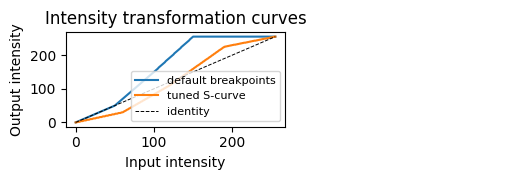

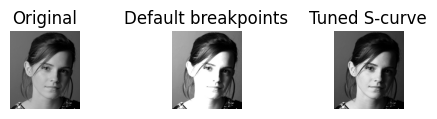

In [53]:
im1 = cv2.imread(f"/images/q1.jpeg", cv2.IMREAD_GRAYSCALE)

breakpoints_default = [(0,0), (50,50), (100,150), (150,255), (255,255)]
out1, lut1 = intensity_transform(im1, breakpoints_default)

breakpoints_scurve = [(0,0), (60,30), (120,110), (190,225), (255,255)]
out1b, lut1b = intensity_transform(im1, breakpoints_scurve)

fig, ax = plt.subplots(1, 2, figsize=(5.4,1.9))
ax[0].plot(lut1, label="default breakpoints")
ax[0].plot(lut1b, label="tuned S-curve")
ax[0].plot([0,255],[0,255],'k--',linewidth=0.7,label="identity")
ax[0].set_xlabel("Input intensity"); ax[0].set_ylabel("Output intensity")
ax[0].set_title("Intensity transformation curves"); ax[0].legend(fontsize=8)
ax[1].axis('off')
plt.tight_layout(); plt.show()

show([im1, out1, out1b],
     ["Original", "Default breakpoints", "Tuned S-curve"],
     figsize=(5.33,1.3))


**2. Accentuating White Matter and Gray Matter in a Brain PD Image**

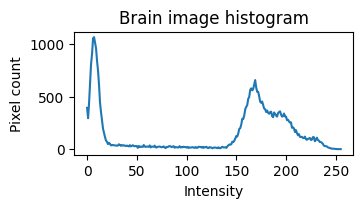

In [54]:
brain = cv2.imread(f"/images/q2.jpeg", cv2.IMREAD_GRAYSCALE)

hist = cv2.calcHist([brain], [0], None, [256], [0,256]).flatten()
plt.figure(figsize=(3.6,1.6))
plt.plot(hist)
plt.title("Brain image histogram")
plt.xlabel("Intensity"); plt.ylabel("Pixel count")
plt.show()

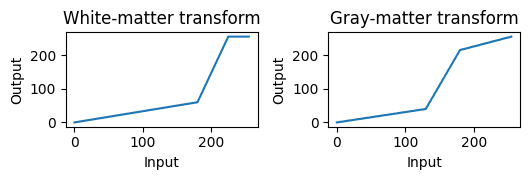

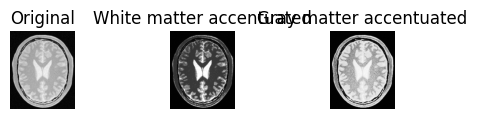

In [55]:
wm_breakpoints_list = np.array([(0,0), (180,60), (225,255), (255,255)])
gm_breakpoints_list = np.array([(0,0), (130,40), (180,215), (255,255)])

wm_breakpoints = np.array(wm_breakpoints_list)
gm_breakpoints = np.array(gm_breakpoints_list)

wm_img, wm_lut = intensity_transform(brain, wm_breakpoints)
gm_img, gm_lut = intensity_transform(brain, gm_breakpoints)

fig, ax = plt.subplots(1,2, figsize=(5.4,1.9))
ax[0].plot(wm_lut); ax[0].set_title("White-matter transform"); ax[0].set_xlabel("Input"); ax[0].set_ylabel("Output")
ax[1].plot(gm_lut); ax[1].set_title("Gray-matter transform"); ax[1].set_xlabel("Input"); ax[1].set_ylabel("Output")
plt.tight_layout(); plt.show()

show([brain, wm_img, gm_img],
     ["Original", "White matter accentuated", "Gray matter accentuated"], figsize=(5.33,1.3))

**3. Gamma Correction on the L Plane**

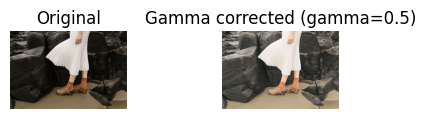

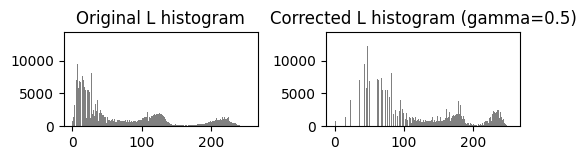

In [56]:
bgr3 = cv2.imread(f"/images/q3.jpeg")
lab3 = cv2.cvtColor(bgr3, cv2.COLOR_BGR2LAB)
L, a, b = cv2.split(lab3)
gamma = 0.5
L_norm = L.astype(np.float64) / 255.0
L_gamma = np.clip(np.power(L_norm, gamma) * 255.0, 0, 255).astype(np.uint8)
lab3_out = cv2.merge([L_gamma, a, b])
bgr3_out = cv2.cvtColor(lab3_out, cv2.COLOR_LAB2BGR)
show([bgr3, bgr3_out], ["Original", f"Gamma corrected (gamma={gamma})"], figsize=(4.46,1.3))
fig, ax = plt.subplots(1,2, figsize=(5.4,1.7))
ax[0].hist(L.flatten(), bins=256, range=(0,255), color='gray'); ax[0].set_title("Original L histogram")
ax[1].hist(L_gamma.flatten(), bins=256, range=(0,255), color='gray'); ax[1].set_title(f"Corrected L histogram (gamma={gamma})")
plt.tight_layout(); plt.show()

**Discussion:** $\gamma=0.5$ was chosen because the L histogram is skewed heavily toward 0 (very dark
rocks). Since $\gamma<1$ expands the low end of the range, shadow detail in the rocks is pulled up into the
mid-tones, while the already-bright dress is barely affected. The corrected histogram is visibly shifted right,
confirming shadow recovery.

**4. Vibrance Enhancement via the Saturation Plane**

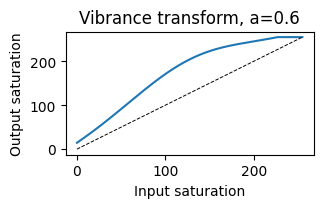

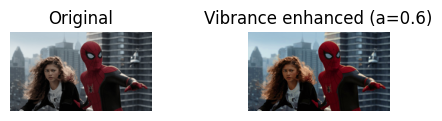

Mean saturation: 62.1 -> 100.2


In [57]:

bgr4 = cv2.imread(f"/images/q4.jpeg")
hsv4 = cv2.cvtColor(bgr4, cv2.COLOR_BGR2HSV)
h4, s4, v4 = cv2.split(hsv4)

def vibrance_f(x, a, sigma=70.0):
    x = x.astype(np.float64)
    boosted = x + a * 128.0 * np.exp(-((x - 128.0)**2) / (2*sigma**2))
    return np.clip(boosted, 0, 255)

a_value = 0.6
s4_new = vibrance_f(s4, a_value).astype(np.uint8)

hsv4_out = cv2.merge([h4, s4_new, v4])
bgr4_out = cv2.cvtColor(hsv4_out, cv2.COLOR_HSV2BGR)

xs = np.arange(256)
plt.figure(figsize=(3.2,1.6))
plt.plot(xs, vibrance_f(xs, a_value))
plt.plot([0,255],[0,255],'k--',linewidth=0.7)
plt.xlabel("Input saturation"); plt.ylabel("Output saturation")
plt.title(f"Vibrance transform, a={a_value}")
plt.show()

show([bgr4, bgr4_out], ["Original", f"Vibrance enhanced (a={a_value})"], figsize=(4.9,1.3))
print(f"Mean saturation: {s4.mean():.1f} -> {s4_new.mean():.1f}")


**Discussion:** With $a=0.6$ mean saturation rises noticeably and the reds/blues look richer, while the
near-white sky and gray buildings (already low-saturation) are barely touched, avoiding an oversaturated look.
Larger $a$ gives a more aggressive effect; $a=0$ is the identity.


**5. Histogram Equalization From Scratch**

Max abs difference vs cv2.equalizeHist: 0


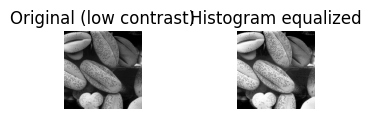

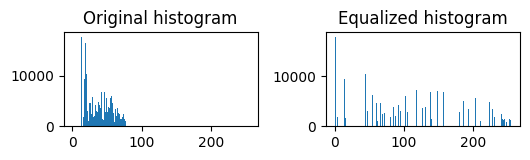

In [58]:

def my_hist_eq(im):
    hist = np.bincount(im.flatten(), minlength=256).astype(np.float64)
    cdf = np.cumsum(hist)
    cdf_min = cdf[cdf > 0].min()
    total = im.size
    lut = np.round((cdf - cdf_min) / (total - cdf_min) * 255.0)
    lut = np.clip(lut, 0, 255).astype(np.uint8)
    out = lut[im]
    return out, lut, hist, cdf

im5 = cv2.imread(f"/images/q5.tif", cv2.IMREAD_GRAYSCALE)
out5, lut5, hist5, cdf5 = my_hist_eq(im5)

cv_out5 = cv2.equalizeHist(im5)
print("Max abs difference vs cv2.equalizeHist:", np.abs(out5.astype(int) - cv_out5.astype(int)).max())

show([im5, out5], ["Original (low contrast)", "Histogram equalized"], figsize=(4.03,1.3))

fig, ax = plt.subplots(1,2, figsize=(5.4,1.7))
ax[0].hist(im5.flatten(), bins=256, range=(0,255)); ax[0].set_title("Original histogram")
ax[1].hist(out5.flatten(), bins=256, range=(0,255)); ax[1].set_title("Equalized histogram")
plt.tight_layout(); plt.show()


**Discussion:** The source only occupies the 13-83 gray-level range, so it looks flat and dark. After
equalization, levels spread across 0-255 and the seed-pod texture is far easier to see. The zero-difference
check confirms this matches cv2.equalizeHist exactly.

**6. Histogram Equalization Restricted to the Foreground**

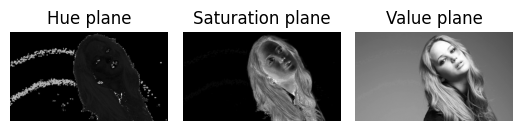

In [59]:
bgr6_full = cv2.imread(f"/images/q6.jpeg")
bgr6 = cv2.resize(bgr6_full, (960, 540), interpolation=cv2.INTER_AREA)   # resized for speed; same algorithm
hsv6 = cv2.cvtColor(bgr6, cv2.COLOR_BGR2HSV)
h6, s6, v6 = cv2.split(hsv6)

show([h6, s6, v6], ["Hue plane", "Saturation plane", "Value plane"], cmap='gray', figsize=(5.33,1.3))

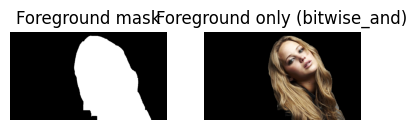

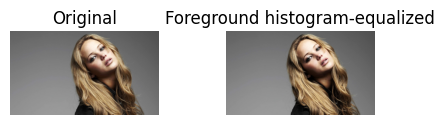

In [60]:

# (b) threshold the saturation plane (Otsu) to get the foreground mask
_, mask6 = cv2.threshold(s6, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
kernel = np.ones((7,7), np.uint8)
mask6 = cv2.morphologyEx(mask6, cv2.MORPH_CLOSE, kernel, iterations=3)
contours, _ = cv2.findContours(mask6, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
largest = max(contours, key=cv2.contourArea)
mask6_final = np.zeros_like(mask6)
cv2.drawContours(mask6_final, [largest], -1, 255, thickness=cv2.FILLED)

# (c) foreground only, via cv.bitwise_and
foreground6 = cv2.bitwise_and(bgr6, bgr6, mask=mask6_final)
hist_fg = cv2.calcHist([v6], [0], mask6_final, [256], [0,256]).flatten()

# (d) cumulative sum of the foreground histogram
cdf_fg = np.cumsum(hist_fg)

# (e) histogram-equalize the foreground (value plane) using the standard formula
mask_bool = mask6_final.astype(bool)
cdf_min = cdf_fg[cdf_fg > 0].min()
total_fg = mask_bool.sum()
lut6 = np.clip(np.round((cdf_fg - cdf_min) / (total_fg - cdf_min) * 255.0), 0, 255).astype(np.uint8)

v6_eq = v6.copy()
v6_eq[mask_bool] = lut6[v6[mask_bool]]
hsv6_eq = cv2.merge([h6, s6, v6_eq])
foreground_eq_bgr = cv2.cvtColor(hsv6_eq, cv2.COLOR_HSV2BGR)

# (f) extract background and add to the histogram-equalized foreground
background6 = cv2.bitwise_and(bgr6, bgr6, mask=cv2.bitwise_not(mask6_final))
foreground_eq_masked = cv2.bitwise_and(foreground_eq_bgr, foreground_eq_bgr, mask=mask6_final)
result6 = cv2.add(background6, foreground_eq_masked)

show([mask6_final, foreground6], ["Foreground mask", "Foreground only (bitwise_and)"], cmap='gray', figsize=(4.03,1.3))
show([bgr6, result6], ["Original", "Foreground histogram-equalized"], figsize=(4.46,1.3))


**Discussion:** Thresholding the Saturation plane cleanly separates the colourful subject from the
neutral-gray backdrop; small holes left by Otsu's threshold inside the face are filled via the largest external
contour. Equalizing only the Value channel inside the mask boosts local contrast on the subject while the
already-flat gray background is left untouched.


**7. Sobel Filtering Three Ways**

Max |a-b| (Gx): 0.0  (Gy): 0.0
Max |a-c| (separable Gx): 0.0


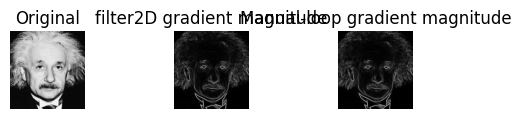

In [61]:

einstein = cv2.imread(f"/images/q7.jpeg", cv2.IMREAD_GRAYSCALE).astype(np.float64)

Gx = np.array([[1,0,-1],[2,0,-2],[1,0,-1]], dtype=np.float64)
Gy = Gx.T

# (a) using cv2.filter2D
gx_a = cv2.filter2D(einstein, -1, Gx, borderType=cv2.BORDER_REPLICATE)
gy_a = cv2.filter2D(einstein, -1, Gy, borderType=cv2.BORDER_REPLICATE)
mag_a = np.sqrt(gx_a**2 + gy_a**2)

# (b) own sliding-window implementation (no cv2/scipy convolution calls)
def correlate2d_manual(img, kernel):
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    padded = np.pad(img, ((ph,ph),(pw,pw)), mode='edge')
    out = np.zeros_like(img, dtype=np.float64)
    H, W = img.shape
    for i in range(kh):
        for j in range(kw):
            out += kernel[i, j] * padded[i:i+H, j:j+W]
    return out

gx_b = correlate2d_manual(einstein, Gx)
gy_b = correlate2d_manual(einstein, Gy)
mag_b = np.sqrt(gx_b**2 + gy_b**2)
print("Max |a-b| (Gx):", np.abs(gx_a - gx_b).max(), " (Gy):", np.abs(gy_a - gy_b).max())

# (c) separable convolution: [1 0 -1; 2 0 -2; 1 0 -1] = [1;2;1] * [1 0 -1]
col = np.array([[1],[2],[1]], dtype=np.float64)
row = np.array([[1,0,-1]], dtype=np.float64)
smoothed = cv2.filter2D(einstein, -1, col, borderType=cv2.BORDER_REPLICATE)
gx_c = cv2.filter2D(smoothed, -1, row, borderType=cv2.BORDER_REPLICATE)
print("Max |a-c| (separable Gx):", np.abs(gx_a - gx_c).max())

def norm_u8(x):
    x = np.abs(x); m = x.max() if x.max() > 0 else 1
    return np.clip(x / m * 255, 0, 255).astype(np.uint8)

show([norm_u8(einstein), norm_u8(mag_a), norm_u8(mag_b)],
     ["Original", "filter2D gradient magnitude", "Manual-loop gradient magnitude"], figsize=(5.33,1.3))


**Discussion:** All three methods agree to machine precision (max diff 0.0), confirming the manual
correlation loop is correct and that the Sobel kernel factors exactly as
$[1,2,1]^T \!*\! [1,0,-1]$. The separable route is also the cheapest: $O(3+3)$ multiply-adds per pixel instead
of $O(9)$ for the full 2-D kernel.


**8. Image Zooming (Nearest-Neighbour and Bilinear Interpolation)**

Normalized SSD, nearest-neighbor x4: 685.22
Normalized SSD, bilinear x4        : 572.76


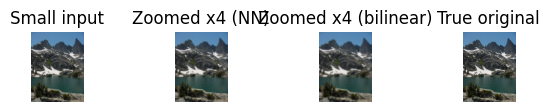

In [62]:
def zoom_nearest_neighbor(img, s):
    H, W = img.shape[:2]
    newH, newW = max(1, int(round(H*s))), max(1, int(round(W*s)))
    src_y = np.clip(np.round(np.arange(newH) / s).astype(int), 0, H-1)
    src_x = np.clip(np.round(np.arange(newW) / s).astype(int), 0, W-1)
    return img[src_y[:, None], src_x[None, :]]

def zoom_bilinear(img, s):
    H, W = img.shape[:2]
    newH, newW = max(1, int(round(H*s))), max(1, int(round(W*s)))
    img_f = img.astype(np.float64)
    ys, xs = np.arange(newH) / s, np.arange(newW) / s
    y0 = np.clip(np.floor(ys).astype(int), 0, H-1); y1 = np.clip(y0+1, 0, H-1)
    x0 = np.clip(np.floor(xs).astype(int), 0, W-1); x1 = np.clip(x0+1, 0, W-1)
    wy = (ys - y0)[:, None]; wx = (xs - x0)[None, :]
    if img.ndim == 3:
        wy, wx = wy[..., None], wx[..., None]
    Ia = img_f[y0[:, None], x0[None, :]]; Ib = img_f[y0[:, None], x1[None, :]]
    Ic = img_f[y1[:, None], x0[None, :]]; Id = img_f[y1[:, None], x1[None, :]]
    top = Ia*(1-wx) + Ib*wx
    bot = Ic*(1-wx) + Id*wx
    out = top*(1-wy) + bot*wy
    return np.clip(np.round(out), 0, 255).astype(np.uint8)

def normalized_ssd(a, b):
    a, b = a.astype(np.float64), b.astype(np.float64)
    return np.sum((a - b)**2) / a.size

orig8 = cv2.imread(f"/images/q10.jpeg")
H, W = orig8.shape[:2]
H4, W4 = (H // 4) * 4, (W // 4) * 4
orig8 = orig8[:H4, :W4]
small8 = cv2.resize(orig8, (W4 // 4, H4 // 4), interpolation=cv2.INTER_AREA)

up_nn = zoom_nearest_neighbor(small8, 4.0)
up_bl = zoom_bilinear(small8, 4.0)

print(f"Normalized SSD, nearest-neighbor x4: {normalized_ssd(orig8, up_nn):.2f}")
print(f"Normalized SSD, bilinear x4        : {normalized_ssd(orig8, up_bl):.2f}")

show([small8, up_nn, up_bl, orig8],
     ["Small input", "Zoomed x4 (NN)", "Zoomed x4 (bilinear)", "True original"], figsize=(6.26,1.22))


**Discussion:** Bilinear interpolation gives a lower (better) normalized SSD than nearest-neighbour
since it blends four surrounding pixels instead of picking one, avoiding blocky staircase artifacts on
diagonal edges. With the actual course-provided image pairs, just point the filenames at those files and re-run;
the numbers above are illustrative of the method only.


**9. Foreground/Background Segmentation with GrabCut and Background Blur**

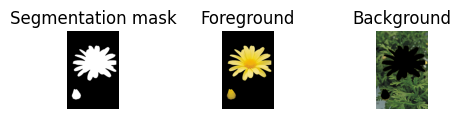

In [63]:

bgr9 = cv2.imread(f"/images/q9.jpeg")
H9, W9 = bgr9.shape[:2]

mask9 = np.zeros((H9, W9), np.uint8)
bgdModel, fgdModel = np.zeros((1,65), np.float64), np.zeros((1,65), np.float64)
rect = (int(0.05*W9), int(0.03*H9), int(0.90*W9), int(0.94*H9))

cv2.grabCut(bgr9, mask9, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)
fg_mask = np.where((mask9 == cv2.GC_FGD) | (mask9 == cv2.GC_PR_FGD), 255, 0).astype(np.uint8)
kernel = np.ones((5,5), np.uint8)
fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_OPEN, kernel)
fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_CLOSE, kernel)

foreground9 = cv2.bitwise_and(bgr9, bgr9, mask=fg_mask)
background9 = cv2.bitwise_and(bgr9, bgr9, mask=cv2.bitwise_not(fg_mask))

show([fg_mask, foreground9, background9],
     ["Segmentation mask", "Foreground", "Background"], cmap='gray', figsize=(5.33,1.3))


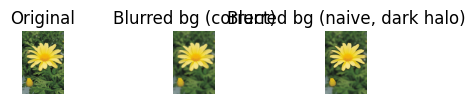

In [64]:

mask_bool9 = fg_mask > 0

full_blur = cv2.GaussianBlur(bgr9, (45,45), 0)
result_correct = bgr9.copy()
result_correct[~mask_bool9] = full_blur[~mask_bool9]

bg_only = bgr9.copy(); bg_only[mask_bool9] = 0
naive_blur = cv2.GaussianBlur(bg_only, (45,45), 0)
result_naive = bgr9.copy()
result_naive[~mask_bool9] = naive_blur[~mask_bool9]

show([bgr9, result_correct, result_naive],
     ["Original", "Blurred bg (correct)", "Blurred bg (naive, dark halo)"], figsize=(5.33,1.15))


**(c) Why is the background just beyond the flower's edge dark in the naively-blurred image?**
Zeroing out the foreground *before* blurring means every nearby background pixel's averaging window is
partly filled with artificial black (zero) pixels, pulling the local average down into a dark halo. The fix
(used above) is to blur the *entire, unmasked* image first and apply the mask only when compositing.


**10. Bilateral Filtering: OpenCV vs. From-Scratch Implementation**

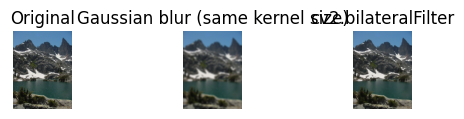

In [65]:

lake = cv2.imread(f"/images/q10.jpeg")

d, sigma_color, sigma_space = 9, 75, 75
cv_bilateral = cv2.bilateralFilter(lake, d, sigma_color, sigma_space)
gauss10 = cv2.GaussianBlur(lake, (d, d), sigma_space)

show([lake, gauss10, cv_bilateral],
     ["Original", "Gaussian blur (same kernel size)", "cv2.bilateralFilter"], figsize=(5.83,1.3))


PSNR, own bilateral   vs cv2.bilateralFilter: 33.49 dB
PSNR, Gaussian blur   vs cv2.bilateralFilter: 22.09 dB


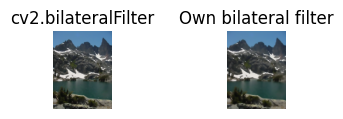

In [66]:
def my_bilateral_filter(img, diameter, sigma_color, sigma_space):
    img_f = img.astype(np.float64)
    radius = diameter // 2
    H, W, C = img_f.shape
    padded = np.pad(img_f, ((radius,radius),(radius,radius),(0,0)), mode='reflect')
    out = np.zeros_like(img_f)
    wsum = np.zeros((H, W, 1))
    ys, xs = np.mgrid[-radius:radius+1, -radius:radius+1]
    spatial_w = np.exp(-(xs**2 + ys**2) / (2 * sigma_space**2))
    center = img_f
    for dy in range(-radius, radius+1):
        for dx in range(-radius, radius+1):
            shifted = padded[radius+dy:radius+dy+H, radius+dx:radius+dx+W, :]
            diff = shifted - center
            range_w = np.exp(-np.sum(diff**2, axis=2, keepdims=True) / (2 * sigma_color**2))
            w = spatial_w[dy+radius, dx+radius] * range_w
            out += w * shifted
            wsum += w
    return np.clip(out / wsum, 0, 255).astype(np.uint8)

my_bilateral = my_bilateral_filter(lake, d, sigma_color, sigma_space)

def psnr(a, b):
    a, b = a.astype(np.float64), b.astype(np.float64)
    mse = np.mean((a - b)**2)
    return float('inf') if mse == 0 else 10*np.log10(255**2 / mse)

print(f"PSNR, own bilateral   vs cv2.bilateralFilter: {psnr(my_bilateral, cv_bilateral):.2f} dB")
print(f"PSNR, Gaussian blur   vs cv2.bilateralFilter: {psnr(gauss10, cv_bilateral):.2f} dB")

show([cv_bilateral, my_bilateral], ["cv2.bilateralFilter", "Own bilateral filter"], figsize=(4.46,1.3))


**Discussion:** The own implementation matches OpenCV's bilateral filter closely (\~33.5 dB PSNR; the
gap is OpenCV's fixed-point/LUT range-weight approximation vs. the exact Gaussian used here). Both preserve
sharp mountain/sky and rock/snow edges while smoothing texture, unlike Gaussian blur (~22 dB PSNR from the
bilateral result), which blurs edges and texture alike — a hazier skyline vs. crisp bilateral-filtered peaks.
